<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_practica_a_senal_profundidad.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_practica_a_senal_profundidad.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_practica_a_senal_profundidad.ipynb)

# SI7011 · Sesión 02 · Práctica A: inspeccionar un MLP profundo
**Juan David Martínez Vargas · Universidad EAFIT**

**Objetivo.** Todavía no buscamos accuracy. Queremos medir, capa por capa, cómo viaja la escala de la señal hacia adelante y hacia atrás en una red profunda:

$$
\operatorname{mean}(a_l),\qquad \operatorname{std}(a_l),\qquad \operatorname{std}(\delta_{a_l}),\qquad \lVert\nabla_{W_l}J\rVert
$$

para distintas profundidades, activaciones e inicializaciones.

> ¿Podemos detectar una mala configuración **antes** de entrenar muchas épocas?

**Duración:** 30 minutos, en clase. El notebook corre en CPU en menos de dos minutos (Kaggle, Colab o local).

**Notación.** $z_l=W_l a_{l-1}+b_l$, $a_l=\phi(z_l)$, $a_0=x$, profundidad $D$. $\delta_{a_l}=\partial J/\partial a_l$ es la señal que viaja hacia atrás; $\nabla_{W_l}J$ es el gradiente del parámetro.

In [1]:
# %pip install torch pandas matplotlib   # descomenta si falta algún paquete
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(4)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
COLORS = {'pytorch': '#7a7a7a', 'small': '#287dad', 'normal': '#c0392b', 'xavier': '#167d78', 'he': '#d58043'}
print('PyTorch', torch.__version__)

PyTorch 2.14.1+cu130


## 1. Un MLP profundo y cinco inicializaciones

Usamos entradas con la forma de la Práctica B (Covertype): $n_0=54$ variables estandarizadas y $C=7$ clases. Aquí las entradas son $x\sim\mathcal N(0,I)$ y las etiquetas son aleatorias: solo nos interesa la **escala** de la señal, no aprender.

| esquema | $W_l$ | $n_\text{in}\operatorname{Var}(W_l)$ |
|---|---|---|
| `pytorch` | valor por defecto de `nn.Linear`: $\mathcal U\big(-1/\sqrt{n_\text{in}},\,1/\sqrt{n_\text{in}}\big)$ | $1/3$ |
| `small` | $\mathcal N(0,\,0.01^2)$ | $\approx 0.03$ con $n_\text{in}=256$ |
| `normal` | $\mathcal N(0,1)$ | $n_\text{in}$ |
| `xavier` | $\mathcal N\big(0,\,2/(n_\text{in}+n_\text{out})\big)$ | $\approx 1$ |
| `he` | $\mathcal N\big(0,\,2/n_\text{in}\big)$ | $2$ |

Recuerda la condición de las diapositivas: con ReLU, cada capa multiplica la varianza por $\tfrac12 n_\text{in}\operatorname{Var}(W)$; con tanh cerca de 0, por $n_\text{in}\operatorname{Var}(W)$.

In [2]:
ACTS = {'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh, 'relu': nn.ReLU}
N_IN, N_OUT, WIDTH = 54, 7, 256


def make_deep_mlp(depth=20, width=WIDTH, act='relu', n_in=N_IN, n_out=N_OUT):
    # depth capas ocultas Linear -> phi, y una capa de salida lineal (logits).
    layers, d = [], n_in
    for _ in range(depth):
        layers += [nn.Linear(d, width), ACTS[act]()]
        d = width
    layers.append(nn.Linear(d, n_out))
    return nn.Sequential(*layers)


@torch.no_grad()
def init_(model, scheme, c=1.0):
    # Reinicializa todas las capas lineales. c escala la varianza de He: Var(W) = c * 2 / n_in.
    for m in model.modules():
        if not isinstance(m, nn.Linear):
            continue
        if scheme == 'pytorch':
            m.reset_parameters()
            continue
        n_in, n_out = m.in_features, m.out_features
        std = {'small': 0.01,
               'normal': 1.0,
               'xavier': math.sqrt(2 / (n_in + n_out)),
               'he': math.sqrt(c * 2 / n_in)}[scheme]
        nn.init.normal_(m.weight, 0.0, std)
        nn.init.zeros_(m.bias)
    return model


x = torch.randn(512, N_IN)
y = torch.randint(0, N_OUT, (512,))
model = init_(make_deep_mlp(depth=20, act='relu'), 'he')
print(model[:4], '...', model[-1])
print('Parámetros:', sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Linear(in_features=54, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
) ... Linear(in_features=256, out_features=7, bias=True)
Parámetros: 1265927


## 2. Medir la señal con *hooks*

Un *forward hook* se ejecuta cada vez que un módulo produce su salida. Lo usamos para guardar $a_l$ después de cada activación y pedir a autograd que conserve su gradiente ($\delta_{a_l}$). Tras **un solo** forward y backward obtenemos, por capa:

- `mean_a`, `std_a`: escala de la señal hacia adelante;
- `std_delta`: escala de la señal hacia atrás $\delta_{a_l}$;
- `grad_W`: norma $\lVert\nabla_{W_l}J\rVert$, lo que realmente usa el optimizador;
- `dead`: fracción de unidades ReLU que valen 0 para **todo** el lote.

In [3]:
def inspect(model, x, y):
    acts = []

    def keep(module, inputs, output):
        output.retain_grad()          # conservar delta_{a_l} = dJ/da_l
        acts.append(output)           # no retornamos nada: la salida no cambia

    hooks = [m.register_forward_hook(keep) for m in model if isinstance(m, tuple(ACTS.values()))]
    model.zero_grad()
    loss = F.cross_entropy(model(x), y)
    loss.backward()
    for h in hooks:
        h.remove()

    linears = [m for m in model if isinstance(m, nn.Linear)][:-1]   # capas ocultas
    is_relu = isinstance(model[1], nn.ReLU)
    df = pd.DataFrame({
        'l': np.arange(1, len(acts) + 1),
        'mean_a': [a.mean().item() for a in acts],
        'std_a': [a.std().item() for a in acts],
        'rms_a': [a.pow(2).mean().sqrt().item() for a in acts],
        'std_delta': [a.grad.std().item() for a in acts],
        'grad_W': [lin.weight.grad.norm().item() for lin in linears],
        'dead': [(a <= 0).all(dim=0).float().mean().item() if is_relu else np.nan for a in acts],
    })
    return df, loss.item()


stats, loss0 = inspect(model, x, y)
print(f'Pérdida inicial: {loss0:.3f}   (ln 7 = {math.log(7):.3f})')
stats.iloc[[0, 1, 2, 9, 14, 19]].round(4)

Pérdida inicial: 2.256   (ln 7 = 1.946)


,l,mean_a,std_a,rms_a,std_delta,grad_W,dead
0,1,0.5642,0.8293,1.0030,0.0002,0.2969,0.0000
1,2,0.5969,0.8480,1.0370,0.0001,0.7853,0.0000
2,3,0.5911,0.8791,1.0593,0.0001,0.9603,0.0000
9,10,0.4693,0.7247,0.8634,0.0002,1.5085,0.1133
14,15,0.5229,0.7737,0.9339,0.0002,2.3507,0.1680
19,20,0.4285,0.6465,0.7756,0.0002,2.8607,0.1953


**Predicción antes de seguir.** Para ReLU y profundidad 20, ¿qué esquema mantendrá `std_a` aproximadamente constante? ¿Cuál hará que desaparezca? ¿Y el valor por defecto de PyTorch? Escribe tu predicción y luego ejecuta la siguiente celda.

## 3. Activaciones × inicializaciones

Repetimos la medición para tres activaciones y cinco esquemas. El eje vertical es logarítmico: una recta indica que cada capa multiplica la escala por el mismo factor.

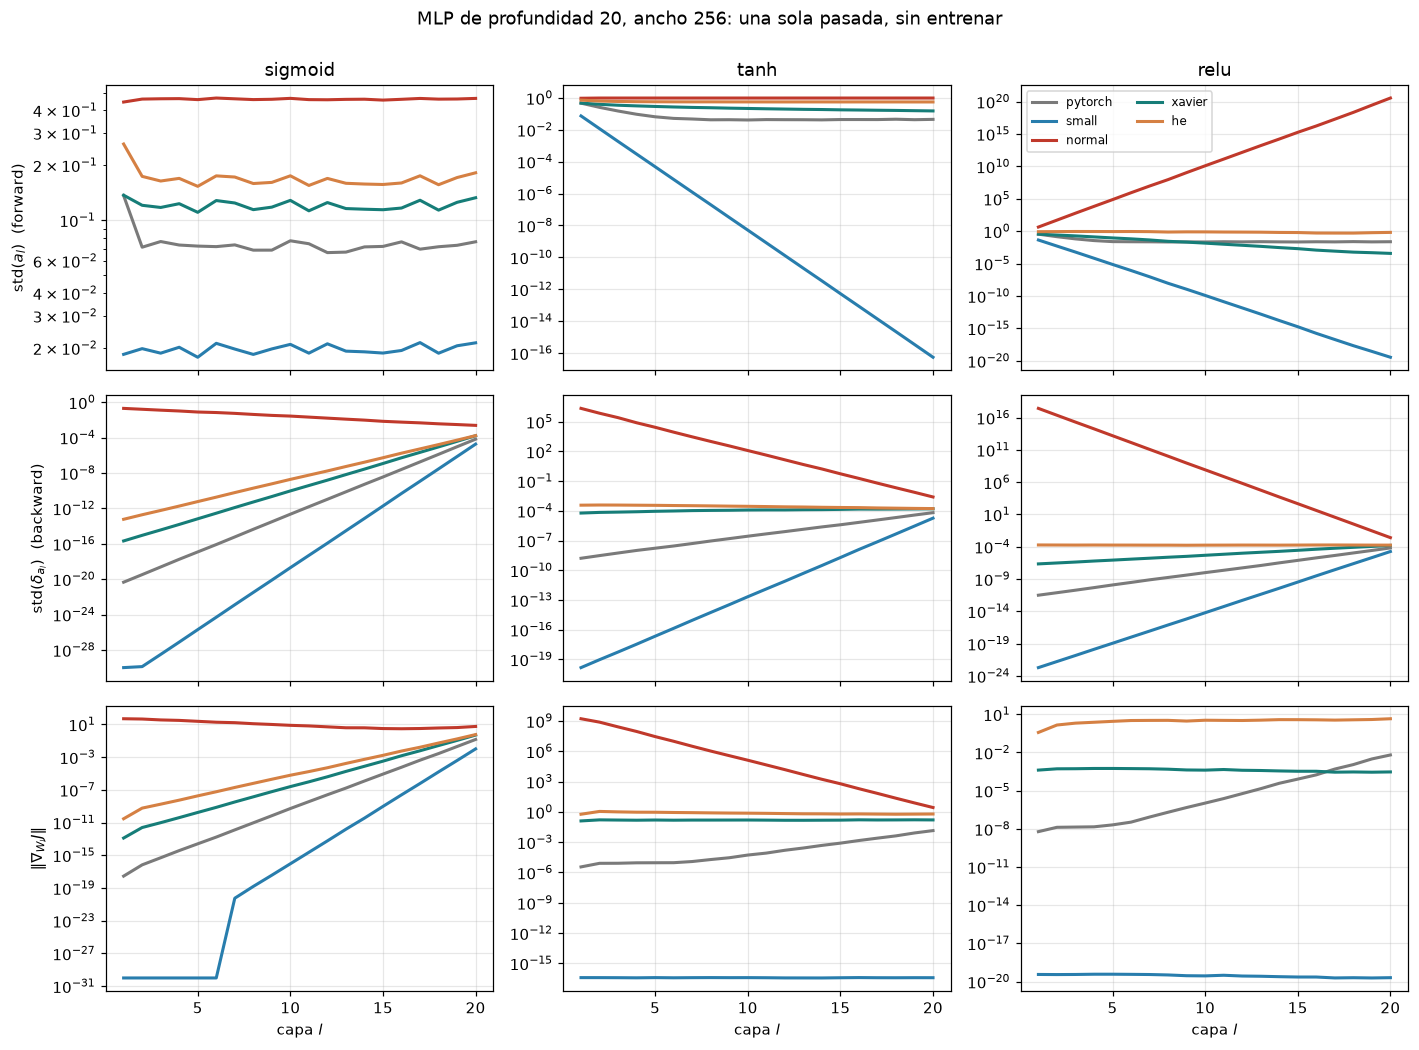

In [4]:
SCHEMES = ['pytorch', 'small', 'normal', 'xavier', 'he']
DEPTH = 20
rows = []
for act in ACTS:
    for scheme in SCHEMES:
        torch.manual_seed(SEED)
        df, l0 = inspect(init_(make_deep_mlp(DEPTH, act=act), scheme), x, y)
        rows.append(df.assign(act=act, scheme=scheme, loss0=l0))
grid = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 9.5), sharex=True)
for j, act in enumerate(ACTS):
    for scheme in SCHEMES:
        d = grid[(grid.act == act) & (grid.scheme == scheme)]
        kw = dict(color=COLORS[scheme], label=scheme, lw=2)
        axes[0, j].semilogy(d.l, d.std_a.clip(lower=1e-30), **kw)
        axes[1, j].semilogy(d.l, d.std_delta.clip(lower=1e-30), **kw)
        axes[2, j].semilogy(d.l, d.grad_W.clip(lower=1e-30), **kw)
    axes[0, j].set_title(act)
axes[0, 0].set_ylabel(r'std$(a_l)$  (forward)')
axes[1, 0].set_ylabel(r'std$(\delta_{a_l})$  (backward)')
axes[2, 0].set_ylabel(r'$\|\nabla_{W_l}J\|$')
for ax in axes[2]:
    ax.set_xlabel('capa $l$')
axes[0, 2].legend(fontsize=8, ncol=2)
fig.suptitle(f'MLP de profundidad {DEPTH}, ancho {WIDTH}: una sola pasada, sin entrenar', y=1.0)
fig.tight_layout()
plt.show()

In [5]:
# Resumen numérico: primera y última capa oculta.
summary = (grid.groupby(['act', 'scheme'], sort=False)
               .apply(lambda d: pd.Series({
                   'std_a[1]': d.std_a.iloc[0], 'std_a[D]': d.std_a.iloc[-1],
                   'grad_W[1]': d.grad_W.iloc[0], 'grad_W[D]': d.grad_W.iloc[-1],
                   'loss0': d.loss0.iloc[0]}), include_groups=False))
summary.style.format('{:.1e}').format('{:.2f}', subset=['loss0'])

**Pregunta A1.** Para ReLU, ¿qué esquemas mantienen `std_a` estable a lo largo de las 20 capas? Relaciona el resultado con la condición $n_\text{in}\operatorname{Var}(W)=2$.

**Pregunta A2.** El valor por defecto de `nn.Linear` tiene $n_\text{in}\operatorname{Var}(W)=1/3$. ¿Por qué factor se multiplica la varianza de $W_l a_{l-1}$ en cada capa ReLU? ¿Qué predice eso para 20 capas? En la gráfica `std_a` no llega a cero: ¿qué la sostiene? (Pista: el sesgo por defecto también es aleatorio.) ¿Qué queda de la información de $x$ en la última capa? Mira también $\lVert\nabla_{W_1}J\rVert$.

**Pregunta A3.** Con `sigmoid`, ninguna inicialización mantiene el gradiente de las primeras capas. ¿Qué propiedad de $\sigma'(z)$ lo explica? ¿Por qué `normal` falla también con `tanh` aunque la señal hacia adelante no desaparezca?

_Respuestas:_

## 4. La varianza se multiplica: el barrido de la animación A01

Con ReLU y $W_l\sim\mathcal N(0,\,c\cdot 2/n_\text{in})$, cada capa multiplica el segundo momento $\mathbb E[a_l^2]$ por $c$. Entonces

$$
\operatorname{rms}(a_l)\approx\operatorname{rms}(a_1)\,c^{(l-1)/2}.
$$

$c=1$ es He. Las líneas discontinuas son la predicción teórica; los puntos, la medición.

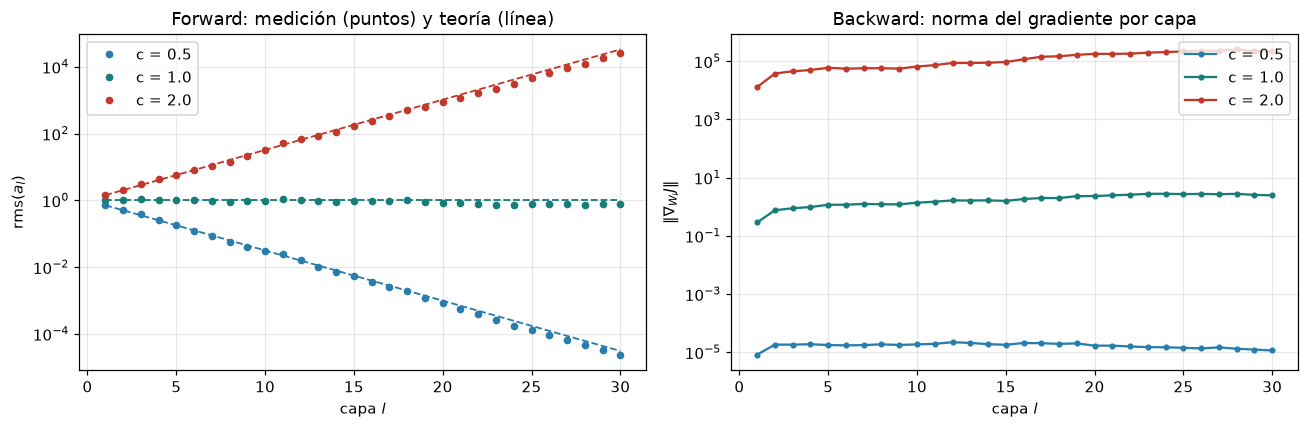

In [6]:
DEPTH_SWEEP = 30
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for c, col in zip([0.5, 1.0, 2.0], ['#287dad', '#167d78', '#c0392b']):
    torch.manual_seed(SEED)
    d, _ = inspect(init_(make_deep_mlp(DEPTH_SWEEP, act='relu'), 'he', c=c), x, y)
    theory = d.rms_a.iloc[0] * c ** ((d.l - 1) / 2)
    axes[0].semilogy(d.l, d.rms_a, 'o', ms=4, color=col, label=f'c = {c}')
    axes[0].semilogy(d.l, theory, '--', color=col, lw=1.2)
    axes[1].semilogy(d.l, d.grad_W, 'o-', ms=3, color=col, label=f'c = {c}')
axes[0].set(xlabel='capa $l$', ylabel=r'rms$(a_l)$', title='Forward: medición (puntos) y teoría (línea)')
axes[1].set(xlabel='capa $l$', ylabel=r'$\|\nabla_{W_l}J\|$', title='Backward: norma del gradiente por capa')
axes[0].legend(); axes[1].legend()
fig.tight_layout(); plt.show()

**Pregunta A4.** Con $c=2$ y $D=30$, ¿por qué factor crece $\operatorname{rms}(a_l)$ entre la primera y la última capa según la fórmula? ¿Coincide con la medición? ¿Qué pasaría con $D=100$?

## 5. ReLUs muertas

Una unidad ReLU con $z<0$ para **todas** las entradas produce 0 y recibe gradiente 0: no se recupera. Simulamos lo que hace una actualización demasiado grande desplazando los sesgos hacia valores negativos en una red con inicialización He.

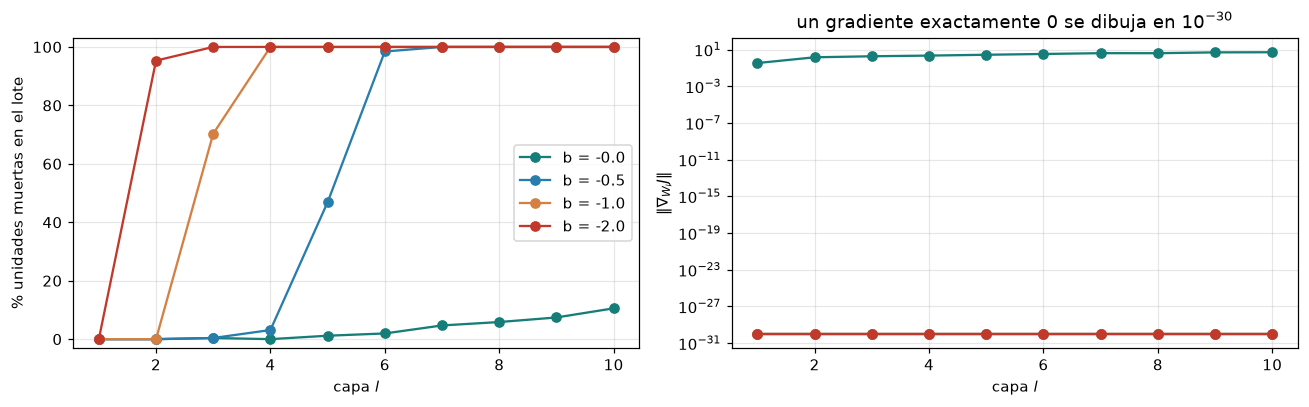

In [7]:
rows = []
for shift in [0.0, 0.5, 1.0, 2.0]:
    torch.manual_seed(SEED)
    m = init_(make_deep_mlp(10, act='relu'), 'he')
    with torch.no_grad():
        for lin in [mod for mod in m if isinstance(mod, nn.Linear)][:-1]:
            lin.bias.fill_(-shift)
    d, l0 = inspect(m, x, y)
    rows.append(d.assign(shift=shift))
dead = pd.concat(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for (shift, d), col in zip(dead.groupby('shift'), ['#167d78', '#287dad', '#d58043', '#c0392b']):
    axes[0].plot(d.l, 100 * d.dead, 'o-', color=col, label=f'b = -{shift}')
    axes[1].semilogy(d.l, d.grad_W.clip(lower=1e-30), 'o-', color=col, label=f'b = -{shift}')
axes[0].set(xlabel='capa $l$', ylabel='% unidades muertas en el lote', ylim=(-3, 103))
axes[1].set(xlabel='capa $l$', ylabel=r'$\|\nabla_{W_l}J\|$', title='un gradiente exactamente 0 se dibuja en $10^{-30}$')
axes[0].legend(); fig.tight_layout(); plt.show()

**Pregunta A5.** ¿Por qué la fracción de unidades muertas aumenta con la profundidad aunque todas las capas tengan el mismo sesgo? ¿Qué activación de las diapositivas evita que el gradiente sea exactamente 0?

## 6. ¿Predice la inspección lo que pasará al entrenar?

Entrenamos la misma arquitectura (ReLU, $D=20$) con cuatro inicializaciones, el mismo optimizador (SGD con momentum) y los mismos datos. Los datos son sintéticos: un "profesor" aleatorio de dos capas asigna una de 7 clases a cada $x\in\mathbb R^{54}$. Así el ejemplo corre en segundos y no depende de descargas.

Primero, la **verificación de la pérdida inicial**: con predicciones casi uniformes sobre $C$ clases, la entropía cruzada empieza cerca de $\ln C$.

In [8]:
torch.manual_seed(0)
teacher = nn.Sequential(nn.Linear(N_IN, 64), nn.Tanh(), nn.Linear(64, N_OUT))
with torch.no_grad():
    X_syn = torch.randn(8192, N_IN)
    y_syn = teacher(3 * X_syn).argmax(dim=1)
print('Frecuencia por clase:', torch.bincount(y_syn, minlength=N_OUT).tolist())

TRAIN_SCHEMES = ['pytorch', 'normal', 'xavier', 'he']
for scheme in TRAIN_SCHEMES:
    torch.manual_seed(SEED)
    with torch.no_grad():
        l0 = F.cross_entropy(init_(make_deep_mlp(20), scheme)(X_syn), y_syn).item()
    print(f'{scheme:8s} pérdida inicial = {l0:10.3f}   (ln 7 = {math.log(7):.3f})')

Frecuencia por clase: [1118, 1244, 1331, 1272, 998, 673, 1556]


pytorch  pérdida inicial =      1.943   (ln 7 = 1.946)
normal   pérdida inicial = 12179188055089461854208.000   (ln 7 = 1.946)


xavier   pérdida inicial =      1.946   (ln 7 = 1.946)
he       pérdida inicial =      2.782   (ln 7 = 1.946)


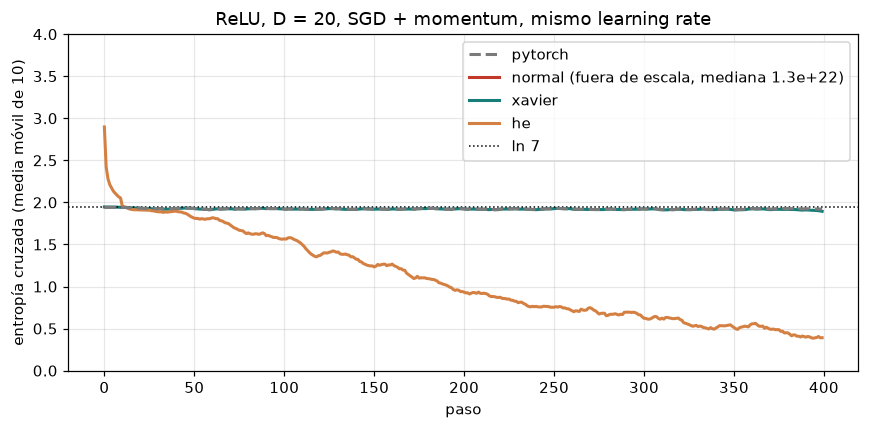

In [9]:
def train_quick(scheme, steps=400, lr=0.02, batch=256):
    torch.manual_seed(SEED)
    m = init_(make_deep_mlp(20), scheme)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    g = torch.Generator().manual_seed(SEED)
    hist = []
    for step in range(steps):
        idx = torch.randint(0, len(X_syn), (batch,), generator=g)
        loss = F.cross_entropy(m(X_syn[idx]), y_syn[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        hist.append(loss.item() if math.isfinite(loss.item()) else np.nan)
    return hist


curves = {s: train_quick(s) for s in TRAIN_SCHEMES}
fig, ax = plt.subplots(figsize=(8, 4))
for s, h in curves.items():
    h = pd.Series(h)
    if h.isna().all():
        label = f'{s} (NaN: diverge)'
    elif h.median() > 4:
        label = f'{s} (fuera de escala, mediana {h.median():.1e})'
    else:
        label = s
    ax.plot(h.rolling(10, min_periods=1).mean(), color=COLORS[s], lw=2, label=label,
            ls='--' if s == 'pytorch' else '-', zorder=3 if s == 'pytorch' else 2)
ax.axhline(math.log(7), color='k', ls=':', lw=1, label='ln 7')
ax.set(xlabel='paso', ylabel='entropía cruzada (media móvil de 10)', ylim=(0, 4),
       title='ReLU, D = 20, SGD + momentum, mismo learning rate')
ax.legend(); fig.tight_layout(); plt.show()

**Pregunta A6.** Ordena las cuatro inicializaciones según la velocidad con que baja la pérdida. ¿Coincide el orden con lo que predijo la inspección de la sección 3, antes de entrenar? ¿Qué medición habrías mirado primero para descartar una configuración?

**Pregunta A7.** `normal` empieza con una pérdida inicial enorme. ¿Por qué eso es una señal de alarma aunque el modelo "todavía no ha aprendido nada"? Al revés, `pytorch` y `xavier` pasan la verificación $\ln C$ y aun así no entrenan: ¿qué medición de la sección 3 lo revela?

_Respuestas:_

---

### Lo que llevamos a la Práctica B
1. Antes de entrenar: pérdida inicial $\approx\ln C$, `std_a` estable por capa, gradientes finitos y distintos de cero en **todas** las capas.
2. ReLU + He es el punto de partida; el valor por defecto de PyTorch no está pensado para MLP profundos con ReLU.
3. En la Práctica B registraremos estas mediciones y las curvas de entrenamiento en **MLflow** para comparar recetas de forma ordenada.

### Referencias
- Glorot y Bengio (2010), *Understanding the difficulty of training deep feedforward neural networks*, AISTATS.
- He, Zhang, Ren y Sun (2015), *Delving deep into rectifiers*, ICCV.
- [PyTorch · `torch.nn.init`](https://docs.pytorch.org/docs/stable/nn.init.html) y [`register_forward_hook`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook).